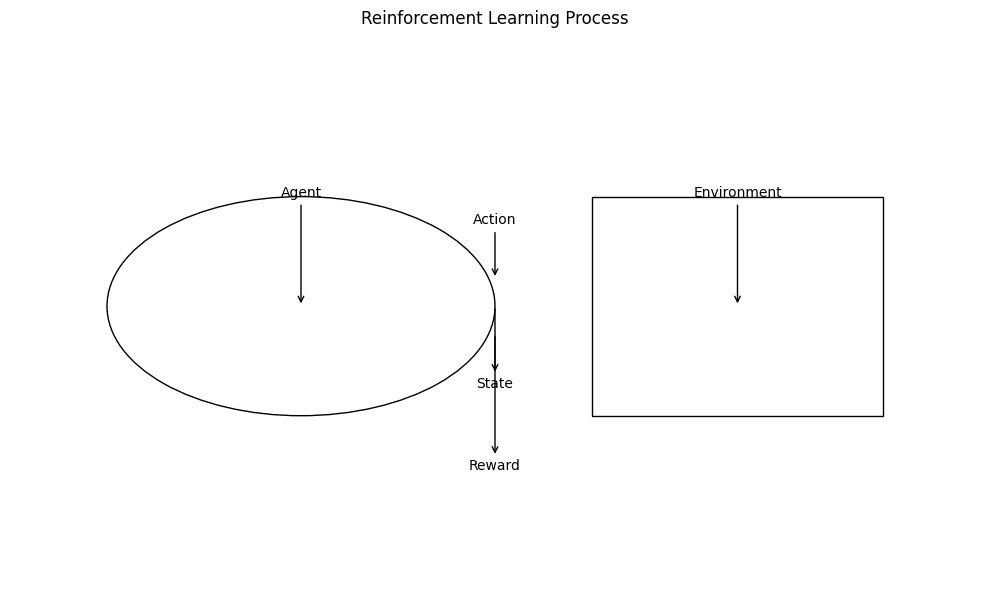

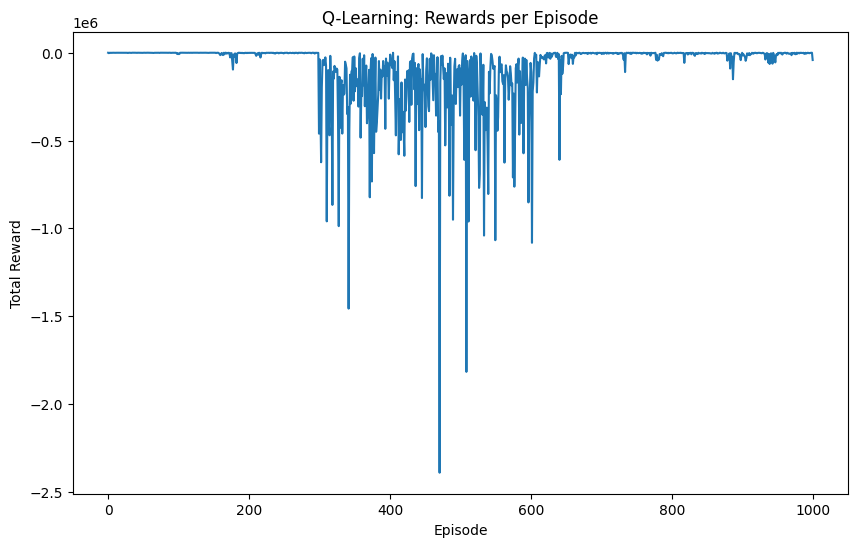

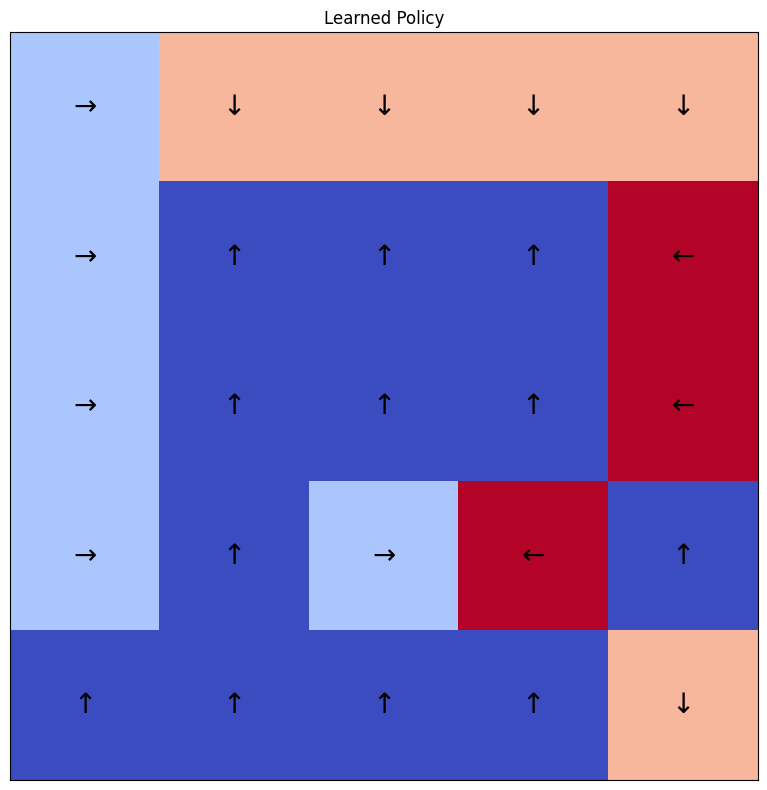

All visualizations have been saved as PNG files.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

def plot_rl_process():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.add_patch(plt.Circle((0.3, 0.5), 0.2, fill=False))
    ax.add_patch(plt.Rectangle((0.6, 0.3), 0.3, 0.4, fill=False))
    ax.annotate('Agent', (0.3, 0.5), xytext=(0.3, 0.7), ha='center', arrowprops=dict(arrowstyle='->'))
    ax.annotate('Environment', (0.75, 0.5), xytext=(0.75, 0.7), ha='center', arrowprops=dict(arrowstyle='->'))
    ax.annotate('Action', (0.5, 0.55), xytext=(0.5, 0.65), ha='center', arrowprops=dict(arrowstyle='->'))
    ax.annotate('State', (0.5, 0.45), xytext=(0.5, 0.35), ha='center', arrowprops=dict(arrowstyle='<-'))
    ax.annotate('Reward', (0.5, 0.5), xytext=(0.5, 0.2), ha='center', arrowprops=dict(arrowstyle='<-'))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.title('Reinforcement Learning Process')
    plt.tight_layout()
    plt.show()
    plt.savefig('rl_process.png', dpi=300, bbox_inches='tight')
    plt.close()z

class GridWorld:
    def __init__(self, size=5):
        self.size = size
        self.state = [0, 0]
        self.goal = [size-1, size-1]
        
    def reset(self):
        self.state = [0, 0]
        return self.state
    
    def step(self, action):
        if action == 0:  # up
            self.state[0] = max(0, self.state[0] - 1)
        elif action == 1:  # right
            self.state[1] = min(self.size - 1, self.state[1] + 1)
        elif action == 2:  # down
            self.state[0] = min(self.size - 1, self.state[0] + 1)
        elif action == 3:  # left
            self.state[1] = max(0, self.state[1] - 1)
        
        done = (self.state == self.goal)
        reward = 1 if done else -0.1
        return self.state, reward, done

class QLearningAgent:
    def __init__(self, state_size, action_size, learning_rate=0.1, discount_factor=0.99, epsilon=0.1):
        self.q_table = torch.zeros((state_size, state_size, action_size))
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        
    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(4)
        return torch.argmax(self.q_table[state[0], state[1]]).item()
    
    def update_q_table(self, state, action, reward, next_state):
        current_q = self.q_table[state[0], state[1], action]
        next_max_q = torch.max(self.q_table[next_state[0], next_state[1]])
        new_q = current_q + self.lr * (reward + self.gamma * next_max_q - current_q)
        self.q_table[state[0], state[1], action] = new_q

def train_agent(env, agent, episodes=1000):
    rewards_per_episode = []
    
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            action = agent.get_action(state)
            next_state, reward, done = env.step(action)
            agent.update_q_table(state, action, reward, next_state)
            state = next_state
            total_reward += reward
        
        rewards_per_episode.append(total_reward)
    
    return rewards_per_episode

def plot_learning_curve(rewards):
    plt.figure(figsize=(10, 6))
    plt.plot(rewards)
    plt.title('Q-Learning: Rewards per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()
    plt.savefig('q_learning_rewards.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_policy(agent, env):
    policy = torch.argmax(agent.q_table, dim=2)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(policy, cmap='coolwarm')
    
    for i in range(env.size):
        for j in range(env.size):
            arrow = ['↑', '→', '↓', '←'][policy[i, j]]
            ax.text(j, i, arrow, ha='center', va='center', fontsize=20)
    
    ax.set_title('Learned Policy')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()
    plt.savefig('learned_policy.png', dpi=300, bbox_inches='tight')
    plt.close()

class DQN(nn.Module):
    def __init__(self, input_size, output_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, output_size)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

class DQNAgent:
    def __init__(self, state_size, action_size, learning_rate=0.001, discount_factor=0.99, epsilon=0.1):
        self.q_network = DQN(state_size, action_size)
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.gamma = discount_factor
        self.epsilon = epsilon
    
    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(4)
        with torch.no_grad():
            q_values = self.q_network(torch.FloatTensor(state))
        return torch.argmax(q_values).item()
    
    def update_q_network(self, state, action, reward, next_state, done):
        state_tensor = torch.FloatTensor(state)
        next_state_tensor = torch.FloatTensor(next_state)
        
        q_values = self.q_network(state_tensor)
        next_q_values = self.q_network(next_state_tensor)
        
        target = q_values.clone()
        target[action] = reward + self.gamma * torch.max(next_q_values) * (1 - done)
        
        loss = nn.MSELoss()(q_values, target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

def main():
    # Plot RL process
    plot_rl_process()

    # Train Q-Learning agent
    env = GridWorld()
    agent = QLearningAgent(env.size, 4)
    rewards = train_agent(env, agent)

    # Plot learning curve
    plot_learning_curve(rewards)

    # Plot learned policy
    plot_policy(agent, env)

    print("All visualizations have been saved as PNG files.")

if __name__ == "__main__":
    main()